In [ ]:
# 머신러닝

# 지도학습 - 정답
    # 분류 - Classification, 회귀 Regression

# 비지도 학습 - 정답이 없음
    # 클러스터링, 군집

# 강화학습
# 딥러닝 - 신경망

# EDA (탐색적 데이터 분석) - 모델 - 추론
    # 데이터 전처리
        # 이상치 제거(대처), 결측치 제거(대처), 새로운 피처 생성
        # 상관지수르르 통한 적절한 변수 선택
        
    # 적절한 모델 선택
    # 평가
    # 추론

In [1]:
# 선형회귀
# y = ax + b
# y 정답
# x 입력값
# a 기울기
# b 절편; 값을 보정하기 위한 미세조정하는 의미

In [3]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 데이터 준비
x = np.array([1,2,3,4,5]).reshape(-1,1) # 공부시간  # x: 학습용 데이터
y = np.array([50,60,65,70,72]) # 점수  # y: 정답
print(x.shape, y.shape)  # 2차원 데이터 O, 1차원 X

# 모델 생성
model = LinearRegression()
 
# 모델 학습
model.fit(x,y)

# 학습 결과
print(f'기울기 : {model.coef_}')
print(f'절편 : {model.intercept_}')

# y = 5.4x + 47.19999

new_x = np.array([5,10,3.5,20]).reshape(-1,1)   # 5시간 공부하면 90점, 10시간 하면 140점...
print(f'새로운데이터 x에 대한 모델이 예측한 값: {model.predict(new_x)}')

(5, 1) (5,)
기울기 : [5.4]
절편 : 47.199999999999996
새로운데이터 x에 대한 모델이 예측한 값: [ 74.2 101.2  66.1 155.2]


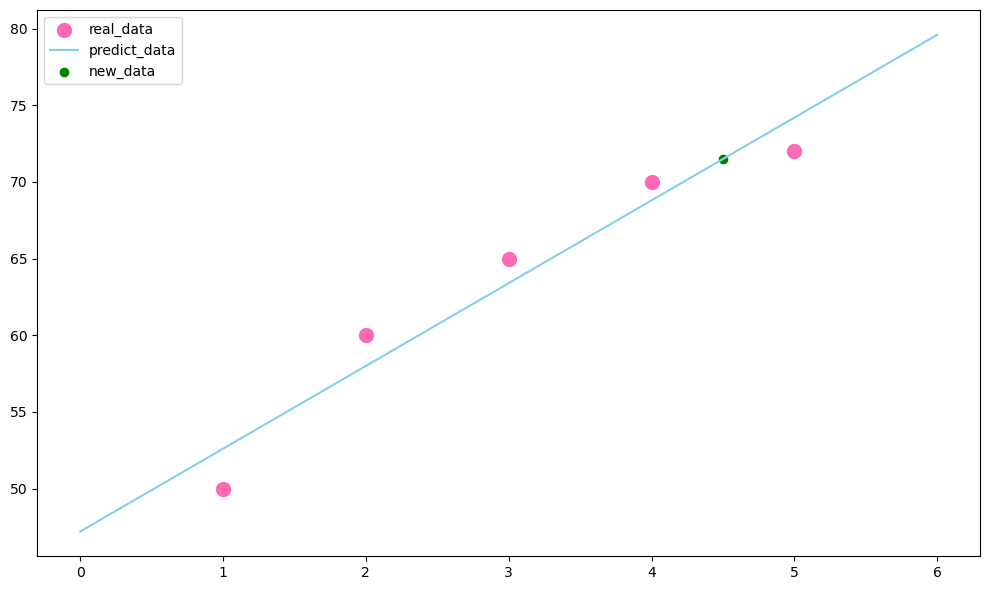

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(x,y,color='hotpink', s=100, label = 'real_data')

# 머신러닝이 예측한 예측 직선
x_line = np.linspace(0,6,100).reshape(-1,1)  # linespace 균등 등할 0부터 6까지 100개
y_line = model.predict(x_line)
ax.plot(x_line, y_line, color = 'skyblue', label = 'predict_data')

# 새로운 예측값
new_x = np.array([[4.5]])
new_y = model.predict(new_x)
ax.scatter(new_x, new_y,color = 'green', label = 'new_data')

plt.legend()
plt.tight_layout()
plt.show()

In [21]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 정규화: 각 원소를 평균으로 뺀 값을 표준편차로 나눔
# -> 안 하면 큰 값이 지배해버림 모든 값의 sclae을 맞춰 안정적으로
data = np.array([10,20,30])
print(data.mean(), data.std())

standard_data = (data - data.mean()) / data.std()
print(standard_data.mean(), round(standard_data.std(),1))

20.0 8.16496580927726
0.0 1.0


(array([ 7., 42., 68., 51., 31., 19., 12.,  7.,  3.,  4.]),
 array([-1.88154652, -1.34418508, -0.80682363, -0.26946218,  0.26789926,
         0.80526071,  1.34262215,  1.8799836 ,  2.41734504,  2.95470649,
         3.49206794]),
 <BarContainer object of 10 artists>)

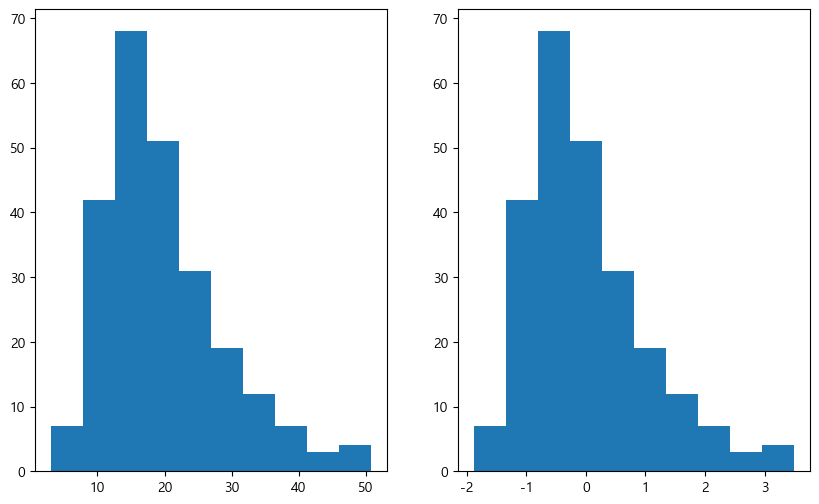

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset('tips')

data = tips['total_bill'].values
fig, axes = plt.subplots(1,2,figsize=(10,6))
axes[0].hist(data)

data_mean = data.mean()
data_std = data.std()
standard_data = (data - data.mean())/data_std
axes[1].hist(standard_data)

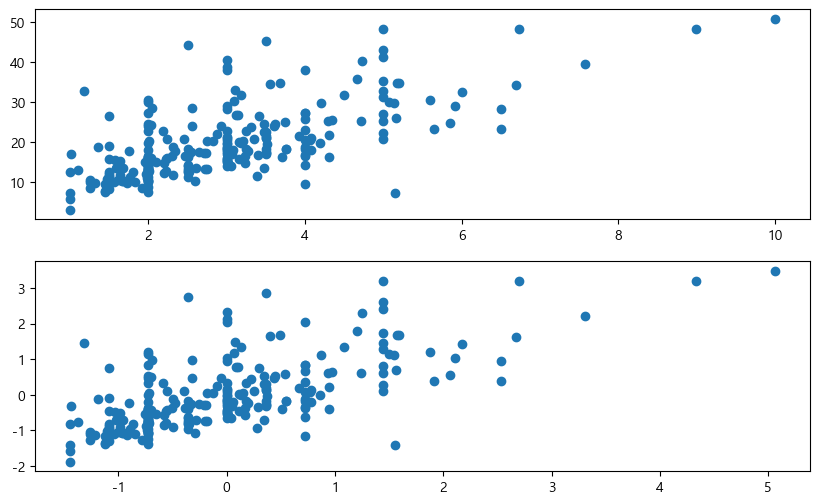

In [ ]:
fig, axes = plt.subplots(2,1,figsize=(10,6))
axes[0].scatter(tips['tip'],tips['total_bill'])

standard_tip = (tips['tip'] - tips['tip'].mean()) / tips['tip'].std()
standard_total_bill = (tips['total_bill'] - tips['total_bill'].mean()) / tips['total_bill'].std()
axes[1].scatter(standard_tip, standard_total_bill)

In [49]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [ ]:
# age 나이
# sex	성별
# bmi 체질량지수
# bp	평균 혈압
# s1 총 혈청 콜레스테롤
# s2 저밀도 지단백
# s3 고밀도 지단백
# s4 총 콜레스테롤
# s5 혈청 중성지방의 로그값
# s6 혈당 수치
# 모든 컬럼은 평균 0, 표준편차 1로 정규화(;단위를 다 맞춰준다) 되어 있음

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

df = load_diabetes(as_frame=True).frame
df.head()

x = df[['bmi']]  # [dataframe] 씌우기 -> 차수 2차원 맞추기
y = df['target']
print(x.shape, y.shape)

# y = ax + b
# 1. 모델 선택
model = LinearRegression()

# 2. 모델 학습
model.fit(x,y)

# 3. 모델 예측(추론)
predicted_model = model.predict(np.array([[0.061696]]))
print(predicted_model) # y값 210.7 나옴 실제값 target 151과는 정확도가 낮음


(442, 1) (442,)
[210.70984199]


c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [52]:
x['bmi'][list(range(442))]

0      0.061696
1     -0.051474
2      0.044451
3     -0.011595
4     -0.036385
         ...   
437    0.019662
438   -0.015906
439   -0.015906
440    0.039062
441   -0.073030
Name: bmi, Length: 442, dtype: float64

In [53]:
x['bmi']

0      0.061696
1     -0.051474
2      0.044451
3     -0.011595
4     -0.036385
         ...   
437    0.019662
438   -0.015906
439   -0.015906
440    0.039062
441   -0.073030
Name: bmi, Length: 442, dtype: float64

In [75]:
import random
random_index = random.sample(range(442),442)  # 0 ~ 441  섞음
x2 =  x['bmi'][random_index]
y2 =  y[random_index]

split_count = int(len(x['bmi'])*0.8)

x2_train = x2[:split_count]
y2_train = y2[:split_count]

x2_test = x2[split_count : ]
y2_test = y2[split_count : ]

model = LinearRegression()

model.fit(x2_train.to_numpy().reshape(-1,1),y2_train)  # 모델 학습

# 예측
predicted =  model.predict(x2_test.to_numpy().reshape(-1,1))

predicted[:5],  y2_test[:5].to_numpy()

from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
mean_absolute_error(y2_test,predicted), mean_squared_error(y2_test,predicted), r2_score(y2_test,predicted)

(50.121093017417856, 3564.0274613797355, 0.37123240457302487)

In [76]:
# 데이터 (x,y)
# 데이터를 섞어서 분할 (학습용과 테스트용)
# 적절한 모델 선택
# 학습 (학습용 데이터로)
# 추론 (예측 -> 테스트용 데이터로)
# 평가 : 테스트용 데이터의 실제 정답 vs 모델이 테스트용 데이터로 예측한 값의 오차

In [ ]:
# 섞는다
# train_test_split
from sklearn.model_selection import train_test_split

x = df[['bmi', 'bp']].to_numpy()
y = df['target'].to_numpy()
x_train,x_test, y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)
model = LinearRegression()

# 학습
model.fit(x_train, y_train)
# 예측
predicted = model.predict(x_test)
# 평가
mean_absolute_error(y_test, predicted), mean_absolute_error(y_test, predicted),r2_score(y_test, predicted)


(50.044114874192104, 50.044114874192104, 0.2939977566766083)

In [92]:
y = np.array([1,2,3,4])

y_hat = np.array([1.2,1.9,3.2,3.7])

# 평균
y_mean = y.mean()

# SS_tot: 데이터 자체의 변동성 오차제곱의 합(데이터의 퍼짐정도)
SS_tot = sum((y - y_mean)**2)

# SS_res: 모델 오차(모델이 틀린 총양)
SS_res = sum((y - y_hat)**2)

# R2_score(결정계수) 1 - SS_res/SS_tot
SS_res - SS_tot

print(f'결정계수: {1 - SS_res/SS_tot}')
print(f'전체변동: {SS_tot}')
print(f'모델이 못 맞춘 부분: {SS_res}')
print(f'모델이 설명한 부분: {SS_tot-SS_res}')

결정계수: 0.964
전체변동: 5.0
모델이 못 맞춘 부분: 0.17999999999999997
모델이 설명한 부분: 4.82


In [93]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 데이터, 데이터 분리(훈련데이터, 평가데이터), 학습(훈련데이터), 평가(평가용 대이터)
# --> 평가함수를 통해 성능을 지표로 표현

# 1. 데이터 로드
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
# 2개의 변수 선택
feature_cols = ['bmi', 'bp']
x = df[feature_cols]
y = df['target']

# 2. 데이터 분리
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=40)

# 3. 파이프라인 구성(전처리 스케일링과 선형회귀를 묶어)
pipeline = Pipeline(steps = [
    ('sclaer', StandardScaler()),('model', LinearRegression())
])
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)
print(r2_score(y_test,y_pred))

0.31709000017431
